In [2]:
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.signal import butter, sosfiltfilt
import os 


In [3]:
def segment_audio(file_path, segment_length=3, overlap=0.5, sr=22050):
    y, sr = librosa.load(file_path, sr=sr)

    segment_samples = int(segment_length * sr)
    step = int(segment_samples * (1 - overlap))

    segments = []

    for start in range(0, len(y) - segment_samples + 1, step):
        end = start + segment_samples
        segments.append(y[start:end])

    return segments

In [4]:
def bandpass_filter(y: np.ndarray, sr: int, low_hz: int, high_hz: int) -> np.ndarray:
    nyquist = sr / 2.0
    low = max(low_hz / nyquist, 0.001)
    high = min(high_hz / nyquist, 0.999)
    if low >= high:
        return y
    sos = butter(4, [low, high], btype="band", output="sos")
    return sosfiltfilt(sos, y).astype(np.float32)

In [5]:
def augment_spectrograms(
    X: np.ndarray, y_mood: np.ndarray, y_voc: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Augment on mel spectrograms: time-shift, freq-mask, noise."""
    X_aug, mood_aug, voc_aug = [X], [y_mood], [y_voc]

    for i in range(len(X)):
        spec = X[i]

        # Time shift Â±10%
        shift = int(spec.shape[1] * 0.1 * np.random.uniform(-1, 1))
        shifted = np.roll(spec, shift, axis=1)
        X_aug.append(shifted)
        mood_aug.append(y_mood[i])
        voc_aug.append(y_voc[i])

        # Frequency masking (mask 5-15 mel bands)
        freq_masked = spec.copy()
        n_mask = np.random.randint(5, 16)
        f_start = np.random.randint(0, max(1, spec.shape[0] - n_mask))
        freq_masked[f_start : f_start + n_mask, :] = 0
        X_aug.append(freq_masked)
        mood_aug.append(y_mood[i])
        voc_aug.append(y_voc[i])

        # Gaussian noise
        noise = np.random.normal(0, 0.02, spec.shape).astype(np.float32)
        noisy = np.clip(spec + noise, 0.0, 1.0)
        X_aug.append(noisy)
        mood_aug.append(y_mood[i])
        voc_aug.append(y_voc[i])

    return (
        np.array(X_aug, dtype=np.float32),
        np.array(mood_aug, dtype=np.float32),
        np.array(voc_aug, dtype=np.float32),
    )

In [6]:
def build_dataset(files, labels, sr=22050, segment_length=3, overlap=0.5,
                  n_mels=64, rms_threshold=0.01):
    X = []
    y = []

    for path, label in zip(files, labels):
        if not path.lower().endswith('.wav'):
            continue

        segmentos = segment_audio(path, segment_length=segment_length, overlap=overlap, sr=sr)

        for segment in segmentos:
            rms = librosa.feature.rms(y=segment).mean()
            if rms < rms_threshold:
                continue

            # aplicar filtros al segmento (no a las etiquetas)
            segment = bandpass_filter(segment, sr, 800, 10000)
            segment, _ = librosa.effects.hpss(segment)

            mel = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=n_mels)
            log_mel = librosa.power_to_db(mel, ref=np.max)
            log_mel = (log_mel + 80) / 80

            X.append(log_mel)
            y.append(label)

    X = np.array(X, dtype=np.float32)[..., np.newaxis]
    y = np.array(y, dtype=np.int32)
    return X, y


In [4]:
carpeta  = r'C:\Users\WINDOWS\Documents\Maracuya\Archivos_audio\Estres'
carpeta2 = r'C:\Users\WINDOWS\Documents\Maracuya\Archivos_audio\Feliz'

file_paths = []
labels = []

In [5]:
for nombre in os.listdir(carpeta):
    if nombre.lower().endswith('.wav'):
        ruta_completa = os.path.join(carpeta, nombre)
        file_paths.append(ruta_completa)
        labels.append(0)  # EstrÃ©s = 0

for nombre in os.listdir(carpeta2):
    if nombre.lower().endswith('.wav'):
        ruta_completa = os.path.join(carpeta2, nombre)
        file_paths.append(ruta_completa)
        labels.append(1)

In [6]:
train_files, test_files, y_train_files, y_test_files = train_test_split(
    file_paths, labels, test_size=0.2, random_state=77, stratify=labels
)

In [7]:
X_train, y_train = build_dataset(train_files, y_train_files, sr=22050)
X_test,  y_test  = build_dataset(test_files,  y_test_files,  sr=22050)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

c:\Users\WINDOWS\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_train: (1130, 64, 130, 1) y_train: (1130,)
X_test : (263, 64, 130, 1) y_test : (263,)


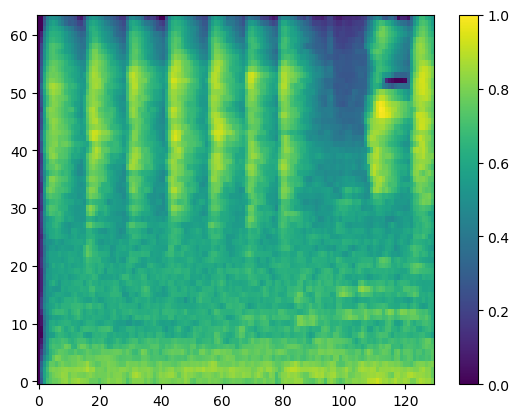

In [9]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0,:,:,0], aspect='auto', origin='lower')
plt.colorbar()
plt.show()

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

In [18]:
def make_model(input_shape=(64,130,1),
               num_filters=16,
               conv_activation='relu',
               pooling_size=(2,2),
               dense_activation='sigmoid'):
  model = keras.Sequential([
          keras.layers.Input(shape=input_shape),

          keras.layers.Conv2D(num_filters, (3,3),
                        padding='same',
                        activation=conv_activation),

          keras.layers.MaxPooling2D(pooling_size),

          keras.layers.Conv2D(num_filters*2, (3,3),
                        padding='same',
                        activation=conv_activation),

          keras.layers.MaxPooling2D(pooling_size),

          keras.layers.Flatten(),
          keras.layers.Dense(64, activation='relu'),
          keras.layers.Dense(1, activation=dense_activation)
      ])

  return model

In [25]:
epochs = 50
batch_size = 16
model = make_model(input_shape=(64,130,1),
               num_filters=16,
               conv_activation='relu',
               pooling_size=(2,2),
               dense_activation='sigmoid')
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early],
    verbose=1
)

Epoch 1/100
71/71 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 4s 29ms/step - accuracy: 0.7106 - loss: 0.5505 - val_accuracy: 0.8137 - val_loss: 0.4187
Epoch 2/100
71/71 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2s 27ms/step - accuracy: 0.8230 - loss: 0.4054 - val_accuracy: 0.8175 - val_loss: 0.4459
Epoch 3/100
71/71 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2s 30ms/step - accuracy: 0.8398 - loss: 0.3825 - val_accuracy: 0.8023 - val_loss: 0.3892
Epoch 4/100
71/71 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 3s 32ms/step - accuracy: 0.8735 - loss: 0.3191 - val_accuracy: 0.8555 - val_loss: 0.3067
Epoch 5/100
71/71 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2s 26ms/step - accuracy: 0.8788 - loss: 0.2989 - val_accuracy: 0.8213 - val_loss: 0.3989
Epoch 6/100
71/71 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2s 26ms/step - accuracy: 0.8894 - loss: 0.2692 - val_accuracy: 0.8251 - val_loss:

In [26]:
model.evaluate(X_test,y_test)

9/9 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 16ms/step - accuracy: 0.8555 - loss: 0.3067


[0.3066713809967041, 0.855513334274292]

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [27]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

9/9 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 22ms/step
[[111  24]
 [ 14 114]]
              precision    recall  f1-score   support

           0      0.888     0.822     0.854       135
           1      0.826     0.891     0.857       128

    accuracy                          0.856       263
   macro avg      0.857     0.856     0.855       263
weighted avg      0.858     0.856     0.855       263



In [28]:
model.save("modelo_periquitos.keras")